# 04 — Transfer Learning with ResNet18

## Bainite vs Martensite Classification

Notebook 03 baseline:

| Evaluation | Accuracy | Balanced Accuracy | Macro-F1 | ROC-AUC |
|---|---:|---:|---:|---:|
| Standard stratified | 0.7809 | 0.7781 | 0.7789 | 0.8582 |
| Unseen physical samples | 0.6487 | 0.6400 | 0.6405 | 0.7094 |

This notebook asks whether **ImageNet-pretrained ResNet18** improves both in-domain classification and, especially, generalization to unseen physical samples.

### CPU-conscious two-stage training
1. **Head adaptation:** freeze the ResNet backbone and train the new classifier.
2. **Partial fine-tuning:** unfreeze `layer4` plus the classifier with a smaller learning rate.

The maximum budget is **40 epochs per experiment (8 + 32)**, but validation-based early stopping prevents wasting CPU time after performance stops improving.


## 1. Configuration


In [1]:
from pathlib import Path

BASELINE_MANIFEST=Path(r"../data/processed/split_baseline_stratified.csv")
GROUPED_MANIFEST=Path(r"../data/processed/split_sample_grouped.csv")
MODEL_DIR=Path(r"../models/04_transfer_learning")
RESULT_DIR=Path(r"../results/04_transfer_learning")

SEED=42
IMAGE_SIZE=160       # CPU-conscious; ResNet supports this via adaptive pooling
BATCH_SIZE=32
NUM_WORKERS=0        # safest on Windows/Jupyter

HEAD_EPOCHS=8
HEAD_LR=1e-3
FINETUNE_EPOCHS=32
FINETUNE_LR=1e-4

WEIGHT_DECAY=1e-4
PATIENCE=8
MIN_DELTA=1e-4
USE_AUGMENTATION=True

print("Maximum epochs per experiment:",HEAD_EPOCHS+FINETUNE_EPOCHS)


Maximum epochs per experiment: 40


## 2. Imports, device, and reproducibility


In [2]:
import copy, random, time, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from torchvision.models import resnet18,ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,balanced_accuracy_score,precision_score,recall_score,
    f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve
)
from IPython.display import display

warnings.filterwarnings("ignore")
MODEL_DIR.mkdir(parents=True,exist_ok=True)
RESULT_DIR.mkdir(parents=True,exist_ok=True)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic=True
        torch.backends.cudnn.benchmark=False

set_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:",torch.__version__)
print("CUDA:",torch.cuda.is_available())
print("Device:",device)
if device.type=="cpu":
    print("CPU threads available:",torch.get_num_threads())


PyTorch: 2.14.0+cpu
CUDA: False
Device: cpu
CPU threads available: 4


## 3. Load the exact Notebook 03 manifests


In [3]:
assert BASELINE_MANIFEST.exists(),"Run Notebook 02 first."
assert GROUPED_MANIFEST.exists(),"Run Notebook 02 first."

baseline_df=pd.read_csv(BASELINE_MANIFEST)
grouped_df=pd.read_csv(GROUPED_MANIFEST)

for name,df in [("standard",baseline_df),("sample_grouped",grouped_df)]:
    required={"image_path","Phase","label","split"}
    assert not (required-set(df.columns)),f"{name}: missing columns"
    assert set(df["split"].unique())=={"train","val","test"}
    assert set(df["label"].unique())=={0,1}
    missing=[p for p in df["image_path"] if not Path(p).exists()]
    assert not missing,f"{name}: {len(missing)} image paths missing."

print("STANDARD")
display(pd.crosstab(baseline_df["split"],baseline_df["Phase"],margins=True))
print("\nSAMPLE-GROUPED")
display(pd.crosstab(grouped_df["split"],grouped_df["Phase"],margins=True))


STANDARD


Phase,Bainite,Martensite,All
split,,,
test,371,423,794
train,1729,1976,3705
val,370,424,794
All,2470,2823,5293



SAMPLE-GROUPED


Phase,Bainite,Martensite,All
split,,,
test,342,418,760
train,1786,2025,3811
val,342,380,722
All,2470,2823,5293


# Part A — Preprocessing

We use ImageNet normalization because the backbone is pretrained on ImageNet. Training augmentation is conservative: horizontal/vertical flips and ±10° rotations. Aggressive contrast/color augmentation is reserved for later domain-robustness experiments.


In [4]:
weights=ResNet18_Weights.DEFAULT
MEAN=[0.485,0.456,0.406]
STD=[0.229,0.224,0.225]

ops=[transforms.Resize((IMAGE_SIZE,IMAGE_SIZE))]
if USE_AUGMENTATION:
    ops += [
        transforms.RandomHorizontalFlip(.5),
        transforms.RandomVerticalFlip(.5),
        transforms.RandomRotation(10),
    ]
ops += [transforms.ToTensor(),transforms.Normalize(MEAN,STD)]
train_transform=transforms.Compose(ops)

eval_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])
print(train_transform)


Compose(
    Resize(size=(160, 160), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. Dataset and DataLoaders


In [5]:
class MicrostructureDataset(Dataset):
    def __init__(self,df,transform=None):
        self.df=df.reset_index(drop=True).copy()
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image=img.convert("RGB")
        if self.transform:image=self.transform(image)
        return image,torch.tensor(int(row["label"]),dtype=torch.long),idx

def make_loaders(df):
    parts={s:df[df["split"]==s].copy() for s in ["train","val","test"]}
    datasets={
        "train":MicrostructureDataset(parts["train"],train_transform),
        "val":MicrostructureDataset(parts["val"],eval_transform),
        "test":MicrostructureDataset(parts["test"],eval_transform),
    }
    g=torch.Generator().manual_seed(SEED)
    common=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,
                pin_memory=torch.cuda.is_available())
    loaders={
        "train":DataLoader(datasets["train"],shuffle=True,generator=g,**common),
        "val":DataLoader(datasets["val"],shuffle=False,**common),
        "test":DataLoader(datasets["test"],shuffle=False,**common),
    }
    return {"parts":parts,"datasets":datasets,"loaders":loaders}


## 5. Visual sanity check


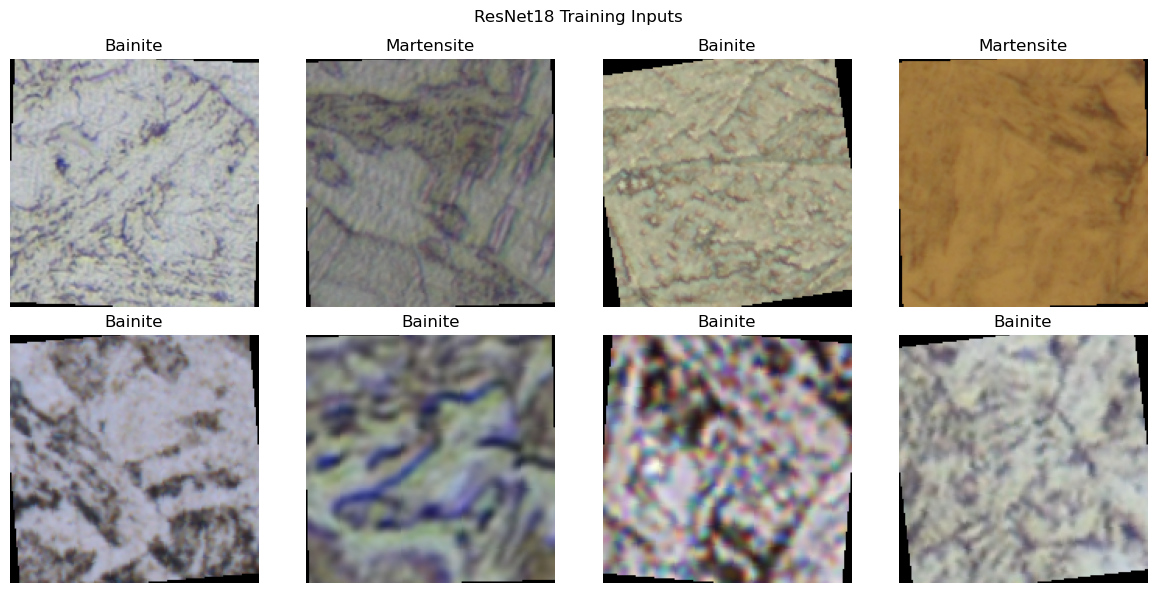

In [6]:
preview=make_loaders(baseline_df)
xb,yb,_=next(iter(preview["loaders"]["train"]))
mean=torch.tensor(MEAN).view(3,1,1);std=torch.tensor(STD).view(3,1,1)

fig,axes=plt.subplots(2,4,figsize=(12,6));axes=np.asarray(axes).ravel()
for i,ax in enumerate(axes):
    img=(xb[i]*std+mean).clamp(0,1)
    ax.imshow(img.permute(1,2,0).numpy())
    ax.set_title("Bainite" if yb[i].item()==0 else "Martensite")
    ax.axis("off")
fig.suptitle("ResNet18 Training Inputs");fig.tight_layout();plt.show()
del preview,xb,yb


# Part B — Pretrained ResNet18

The original ImageNet classifier is replaced by a two-class head with dropout. Stage 1 trains only this head; Stage 2 trains `layer4` and the head.


In [7]:
def build_model():
    m=resnet18(weights=weights)
    n=m.fc.in_features
    m.fc=nn.Sequential(nn.Dropout(.35),nn.Linear(n,2))
    return m

def freeze_backbone(m):
    for p in m.parameters():p.requires_grad=False
    for p in m.fc.parameters():p.requires_grad=True

def unfreeze_layer4(m):
    for p in m.parameters():p.requires_grad=False
    for p in m.layer4.parameters():p.requires_grad=True
    for p in m.fc.parameters():p.requires_grad=True

def parameter_summary(m):
    total=sum(p.numel() for p in m.parameters())
    trainable=sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Total parameters: {total:,}")
    print(f"Trainable: {trainable:,} ({100*trainable/total:.2f}%)")

m=build_model();freeze_backbone(m);print("STAGE 1");parameter_summary(m)
unfreeze_layer4(m);print("\nSTAGE 2");parameter_summary(m)
del m


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:01<00:00, 37.6MB/s]


STAGE 1
Total parameters: 11,177,538
Trainable: 1,026 (0.01%)

STAGE 2
Total parameters: 11,177,538
Trainable: 8,394,754 (75.10%)


# Part C — Metrics and training


In [8]:
def metrics(y,p,prob):
    return {
        "accuracy":accuracy_score(y,p),
        "balanced_accuracy":balanced_accuracy_score(y,p),
        "precision_macro":precision_score(y,p,average="macro",zero_division=0),
        "recall_macro":recall_score(y,p,average="macro",zero_division=0),
        "f1_macro":f1_score(y,p,average="macro",zero_division=0),
        "roc_auc":roc_auc_score(y,prob),
    }

@torch.inference_mode()
def evaluate(model,loader,criterion):
    model.eval();loss_sum=0;y=[];p=[];prob=[];idxs=[]
    for x,t,idx in loader:
        x=x.to(device);t=t.to(device)
        z=model(x);loss=criterion(z,t)
        pr=torch.softmax(z,1)[:,1];pred=z.argmax(1)
        loss_sum+=loss.item()*x.size(0)
        y.extend(t.cpu().numpy());p.extend(pred.cpu().numpy())
        prob.extend(pr.cpu().numpy());idxs.extend(idx.numpy())
    out=metrics(y,p,prob);out["loss"]=loss_sum/len(loader.dataset)
    return out,np.asarray(y),np.asarray(p),np.asarray(prob),np.asarray(idxs)


## 6. Training stage

Validation Macro-F1 selects checkpoints. The test set remains untouched until both training stages are complete.


In [9]:
def run_stage(model,bundle,name,max_epochs,lr,best_f1=-np.inf,best_state=None,offset=0):
    criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,weight_decay=WEIGHT_DECAY
    )
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode="max",factor=.5,patience=3,min_lr=1e-7
    )
    hist=[];stale=0

    for e in range(1,max_epochs+1):
        epoch=offset+e;model.train();loss_sum=0;y=[];p=[];prob=[]
        for x,t,_ in bundle["loaders"]["train"]:
            x=x.to(device);t=t.to(device);optimizer.zero_grad(set_to_none=True)
            z=model(x);loss=criterion(z,t);loss.backward();optimizer.step()
            pr=torch.softmax(z,1)[:,1];pred=z.argmax(1)
            loss_sum+=loss.item()*x.size(0)
            y.extend(t.detach().cpu().numpy());p.extend(pred.detach().cpu().numpy())
            prob.extend(pr.detach().cpu().numpy())

        tm=metrics(y,p,prob)
        tm["loss"]=loss_sum/len(bundle["datasets"]["train"])
        vm,*_=evaluate(model,bundle["loaders"]["val"],criterion)
        scheduler.step(vm["f1_macro"]);current_lr=optimizer.param_groups[0]["lr"]

        hist.append({"epoch":epoch,"stage":name,"lr":current_lr,
                     **{f"train_{k}":v for k,v in tm.items()},
                     **{f"val_{k}":v for k,v in vm.items()}})

        print(f"Epoch {epoch:02d} | {name:9s} | train F1 {tm['f1_macro']:.4f} | "
              f"val F1 {vm['f1_macro']:.4f} | val AUC {vm['roc_auc']:.4f} | "
              f"val loss {vm['loss']:.4f} | lr {current_lr:.1e}")

        if vm["f1_macro"]>best_f1+MIN_DELTA:
            best_f1=vm["f1_macro"];best_state=copy.deepcopy(model.state_dict());stale=0
        else:stale+=1

        if stale>=PATIENCE:
            print(f"Early stopping {name} after {e} stage epochs.")
            break

    return model,pd.DataFrame(hist),best_f1,best_state


## 7. Complete two-stage experiment

Stage 2 starts from the **best Stage-1 weights**, not simply the last head-training epoch. The globally best validation checkpoint is restored for final testing.


In [10]:
def train_experiment(name,df):
    print("\n"+"="*80+"\nEXPERIMENT:",name,"\n"+"="*80)
    set_seed(SEED);bundle=make_loaders(df);model=build_model().to(device);start=time.time()

    freeze_backbone(model)
    print("\nSTAGE 1 — HEAD");parameter_summary(model)
    model,h1,best_f1,best_state=run_stage(
        model,bundle,"head",HEAD_EPOCHS,HEAD_LR
    )

    model.load_state_dict(best_state)
    unfreeze_layer4(model)
    print("\nSTAGE 2 — FINE-TUNE LAYER4");parameter_summary(model)
    model,h2,best_f1,best_state=run_stage(
        model,bundle,"fine_tune",FINETUNE_EPOCHS,FINETUNE_LR,
        best_f1,best_state,len(h1)
    )

    model.load_state_dict(best_state)
    history=pd.concat([h1,h2],ignore_index=True)
    elapsed=(time.time()-start)/60

    checkpoint=MODEL_DIR/f"{name}_resnet18_best.pt"
    torch.save({"model_state_dict":best_state,"architecture":"ResNet18",
                "image_size":IMAGE_SIZE,"label_map":{"Bainite":0,"Martensite":1},
                "best_val_macro_f1":float(best_f1),"seed":SEED},checkpoint)
    history.to_csv(RESULT_DIR/f"{name}_history.csv",index=False)

    criterion=nn.CrossEntropyLoss()
    test_metrics,y,p,prob,idx=evaluate(model,bundle["loaders"]["test"],criterion)

    print("\nTEST RESULTS")
    for k,v in test_metrics.items():print(f"{k:20s}: {v:.4f}")
    print(f"Training time: {elapsed:.2f} min")
    print(f"Best validation Macro-F1: {best_f1:.4f}")

    return {"name":name,"model":model,"bundle":bundle,"history":history,
            "test_metrics":test_metrics,"y_true":y,"y_pred":p,
            "y_prob":prob,"row_indices":idx,"checkpoint":checkpoint,"minutes":elapsed}


# Part D — Experiment 1: Standard stratified split


In [11]:
standard_result=train_experiment("standard_stratified",baseline_df)



EXPERIMENT: standard_stratified 

STAGE 1 — HEAD
Total parameters: 11,177,538
Trainable: 1,026 (0.01%)
Epoch 01 | head      | train F1 0.6227 | val F1 0.7148 | val AUC 0.8098 | val loss 0.5612 | lr 1.0e-03
Epoch 02 | head      | train F1 0.7001 | val F1 0.7266 | val AUC 0.8188 | val loss 0.5304 | lr 1.0e-03
Epoch 03 | head      | train F1 0.6971 | val F1 0.6767 | val AUC 0.8265 | val loss 0.5734 | lr 1.0e-03
Epoch 04 | head      | train F1 0.7098 | val F1 0.7330 | val AUC 0.8258 | val loss 0.5242 | lr 1.0e-03
Epoch 05 | head      | train F1 0.7216 | val F1 0.7374 | val AUC 0.8360 | val loss 0.5023 | lr 1.0e-03
Epoch 06 | head      | train F1 0.7136 | val F1 0.7187 | val AUC 0.8259 | val loss 0.5325 | lr 1.0e-03
Epoch 07 | head      | train F1 0.7267 | val F1 0.7405 | val AUC 0.8382 | val loss 0.5153 | lr 1.0e-03
Epoch 08 | head      | train F1 0.7274 | val F1 0.7419 | val AUC 0.8391 | val loss 0.4981 | lr 1.0e-03

STAGE 2 — FINE-TUNE LAYER4
Total parameters: 11,177,538
Trainable: 8,39

## 8. Learning curves


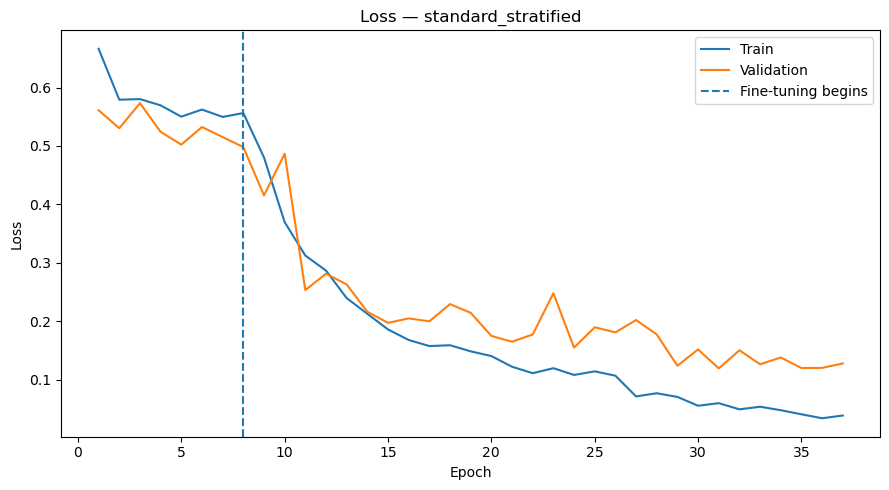

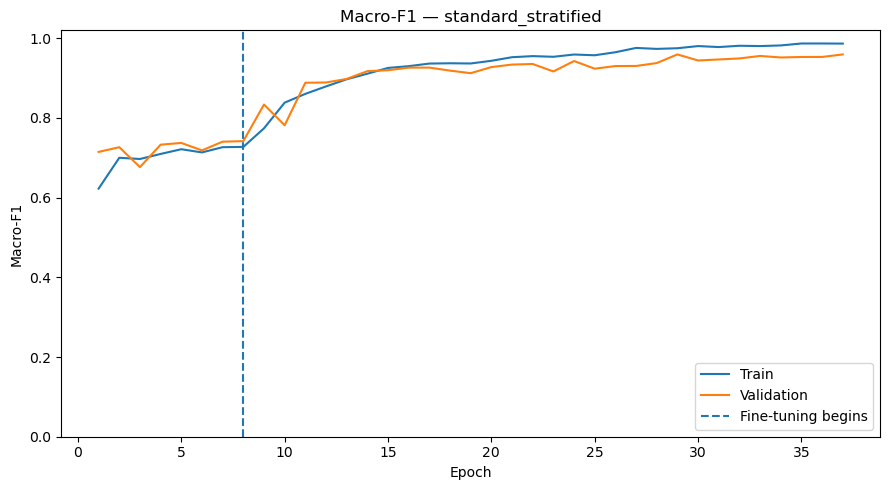

In [12]:
def plot_curves(r):
    h=r["history"]
    fig,ax=plt.subplots(figsize=(9,5))
    ax.plot(h["epoch"],h["train_loss"],label="Train")
    ax.plot(h["epoch"],h["val_loss"],label="Validation")
    ax.axvline(len(h[h["stage"]=="head"]),linestyle="--",label="Fine-tuning begins")
    ax.set_xlabel("Epoch");ax.set_ylabel("Loss");ax.set_title(f"Loss — {r['name']}")
    ax.legend();fig.tight_layout();plt.show()

    fig,ax=plt.subplots(figsize=(9,5))
    ax.plot(h["epoch"],h["train_f1_macro"],label="Train")
    ax.plot(h["epoch"],h["val_f1_macro"],label="Validation")
    ax.axvline(len(h[h["stage"]=="head"]),linestyle="--",label="Fine-tuning begins")
    ax.set_ylim(0,1.02);ax.set_xlabel("Epoch");ax.set_ylabel("Macro-F1")
    ax.set_title(f"Macro-F1 — {r['name']}");ax.legend();fig.tight_layout();plt.show()

plot_curves(standard_result)


# Part E — Experiment 2: Unseen physical samples

This is the critical comparison with Notebook 03's unseen-sample Macro-F1 of **0.6405**.



EXPERIMENT: sample_grouped 

STAGE 1 — HEAD
Total parameters: 11,177,538
Trainable: 1,026 (0.01%)
Epoch 01 | head      | train F1 0.6503 | val F1 0.6365 | val AUC 0.7266 | val loss 0.6319 | lr 1.0e-03
Epoch 02 | head      | train F1 0.7099 | val F1 0.6804 | val AUC 0.7410 | val loss 0.5969 | lr 1.0e-03
Epoch 03 | head      | train F1 0.7319 | val F1 0.6607 | val AUC 0.7534 | val loss 0.6163 | lr 1.0e-03
Epoch 04 | head      | train F1 0.7324 | val F1 0.5838 | val AUC 0.7448 | val loss 0.7105 | lr 1.0e-03
Epoch 05 | head      | train F1 0.7383 | val F1 0.6819 | val AUC 0.7568 | val loss 0.6064 | lr 1.0e-03
Epoch 06 | head      | train F1 0.7275 | val F1 0.6854 | val AUC 0.7526 | val loss 0.6101 | lr 1.0e-03
Epoch 07 | head      | train F1 0.7305 | val F1 0.6296 | val AUC 0.7618 | val loss 0.6467 | lr 1.0e-03
Epoch 08 | head      | train F1 0.7380 | val F1 0.6608 | val AUC 0.7831 | val loss 0.6071 | lr 1.0e-03

STAGE 2 — FINE-TUNE LAYER4
Total parameters: 11,177,538
Trainable: 8,394,754

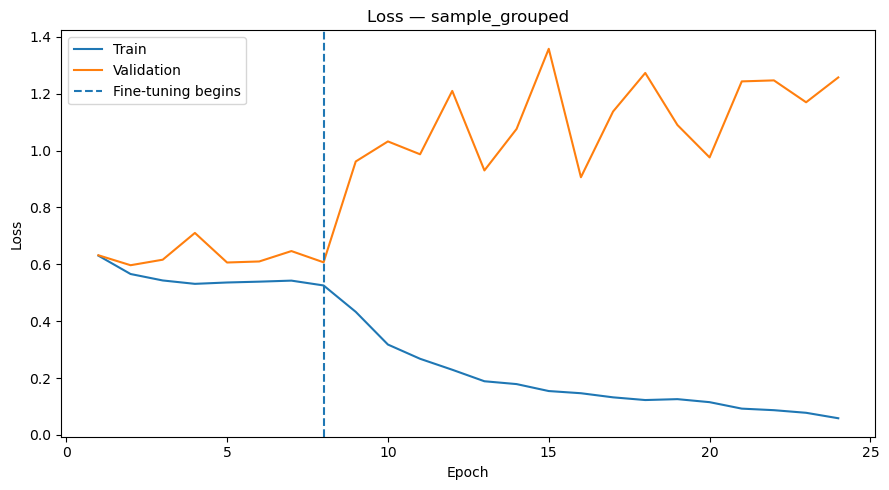

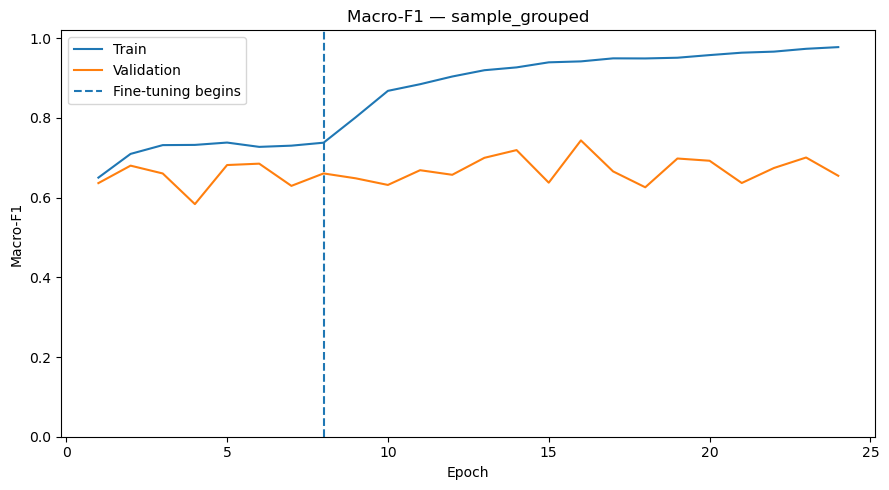

In [13]:
grouped_result=train_experiment("sample_grouped",grouped_df)
plot_curves(grouped_result)


# Part F — Detailed evaluation



 STANDARD_STRATIFIED
              precision    recall  f1-score   support

     Bainite     0.9645    0.9515    0.9579       371
  Martensite     0.9579    0.9693    0.9636       423

    accuracy                         0.9610       794
   macro avg     0.9612    0.9604    0.9608       794
weighted avg     0.9610    0.9610    0.9609       794



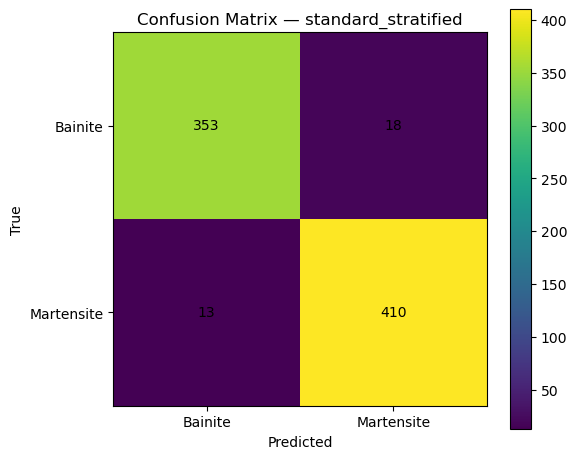

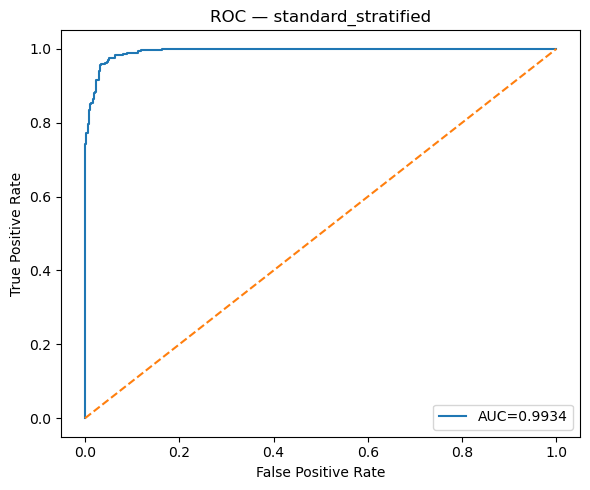


 SAMPLE_GROUPED
              precision    recall  f1-score   support

     Bainite     0.6009    0.8012    0.6867       342
  Martensite     0.7763    0.5646    0.6537       418

    accuracy                         0.6711       760
   macro avg     0.6886    0.6829    0.6702       760
weighted avg     0.6974    0.6711    0.6686       760



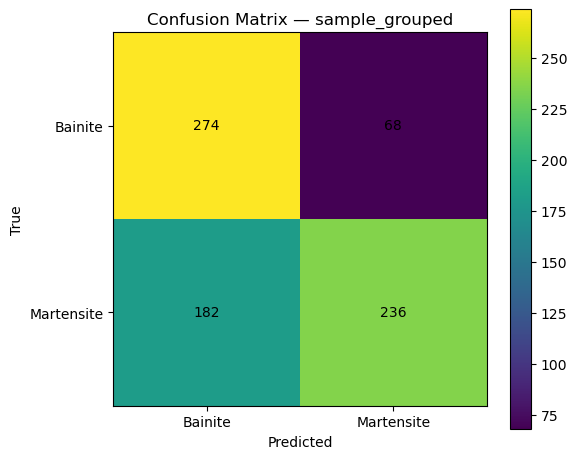

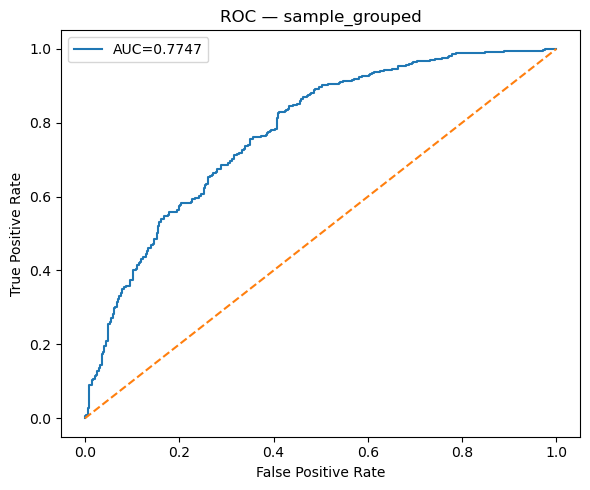

In [14]:
CLASS_NAMES=["Bainite","Martensite"]

def detailed(r):
    y,p,prob=r["y_true"],r["y_pred"],r["y_prob"]
    print("\n",r["name"].upper())
    print(classification_report(y,p,target_names=CLASS_NAMES,digits=4,zero_division=0))

    cm=confusion_matrix(y,p)
    fig,ax=plt.subplots(figsize=(6,5));im=ax.imshow(cm)
    ax.set_xticks([0,1],CLASS_NAMES);ax.set_yticks([0,1],CLASS_NAMES)
    ax.set_xlabel("Predicted");ax.set_ylabel("True");ax.set_title(f"Confusion Matrix — {r['name']}")
    for i in range(2):
        for j in range(2):ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    fig.colorbar(im,ax=ax);fig.tight_layout();plt.show()

    fpr,tpr,_=roc_curve(y,prob);auc=roc_auc_score(y,prob)
    fig,ax=plt.subplots(figsize=(6,5));ax.plot(fpr,tpr,label=f"AUC={auc:.4f}")
    ax.plot([0,1],[0,1],linestyle="--");ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate");ax.set_title(f"ROC — {r['name']}")
    ax.legend();fig.tight_layout();plt.show()

detailed(standard_result)
detailed(grouped_result)


## 9. Confident misclassifications


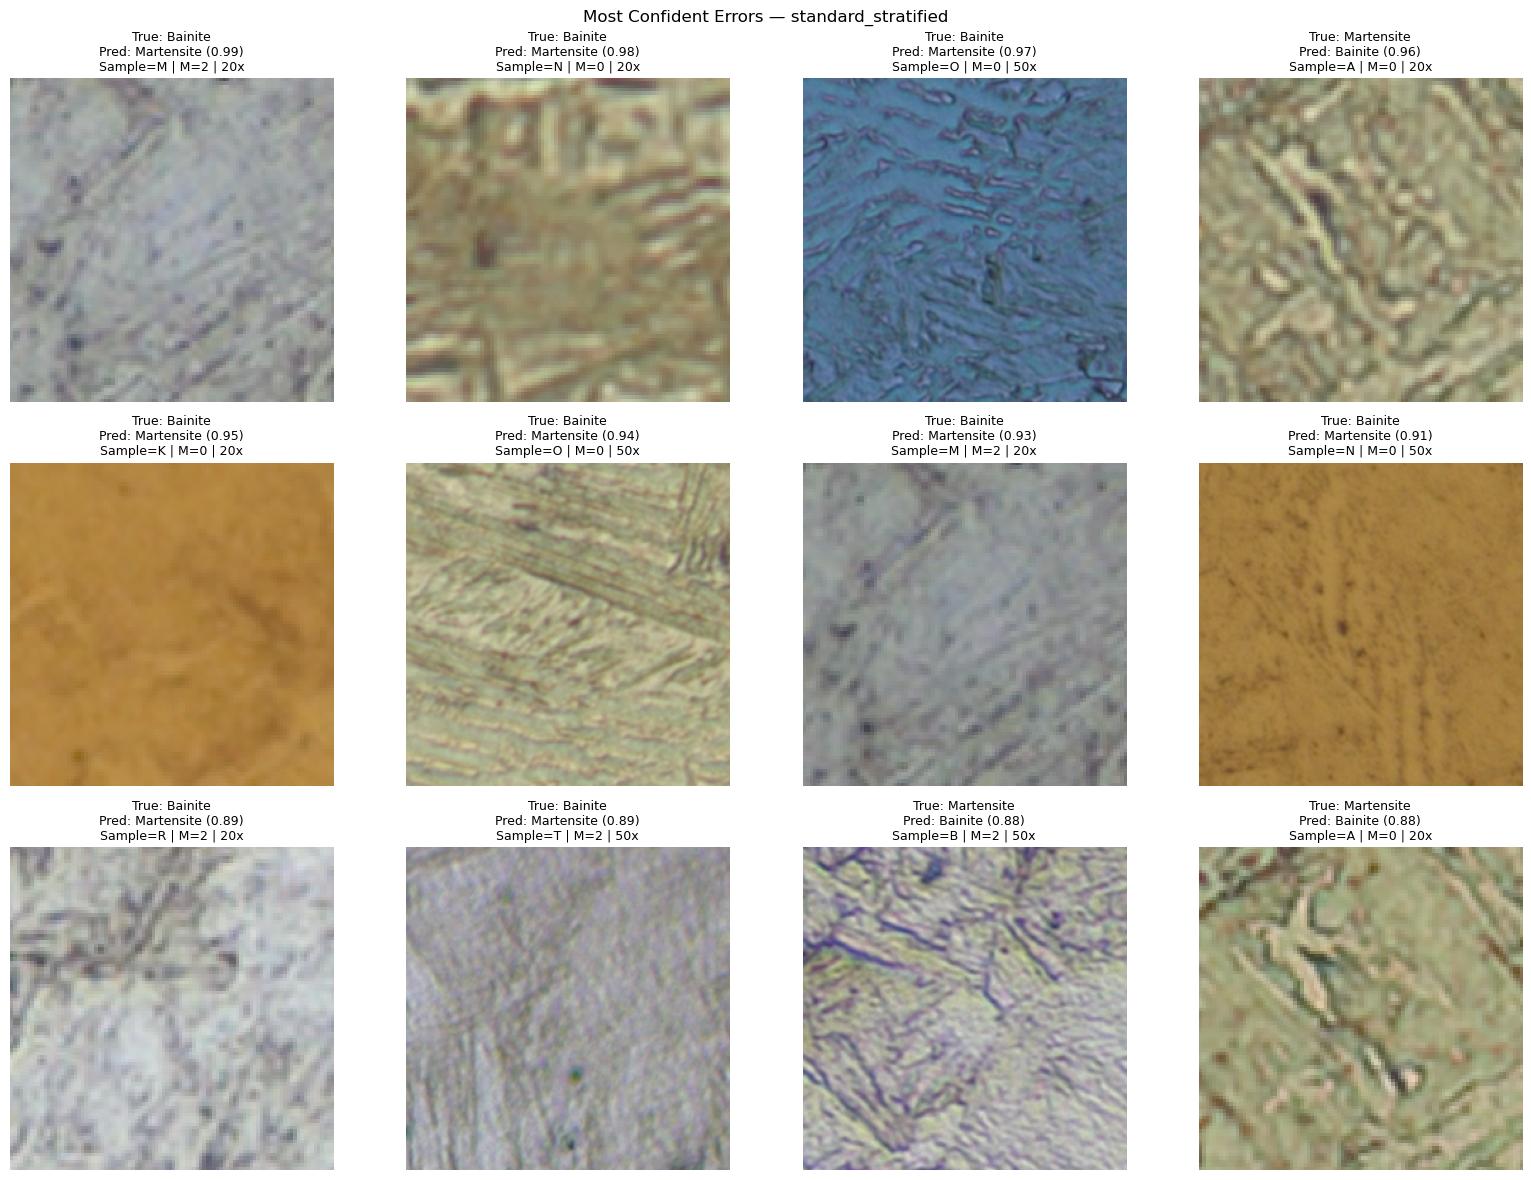

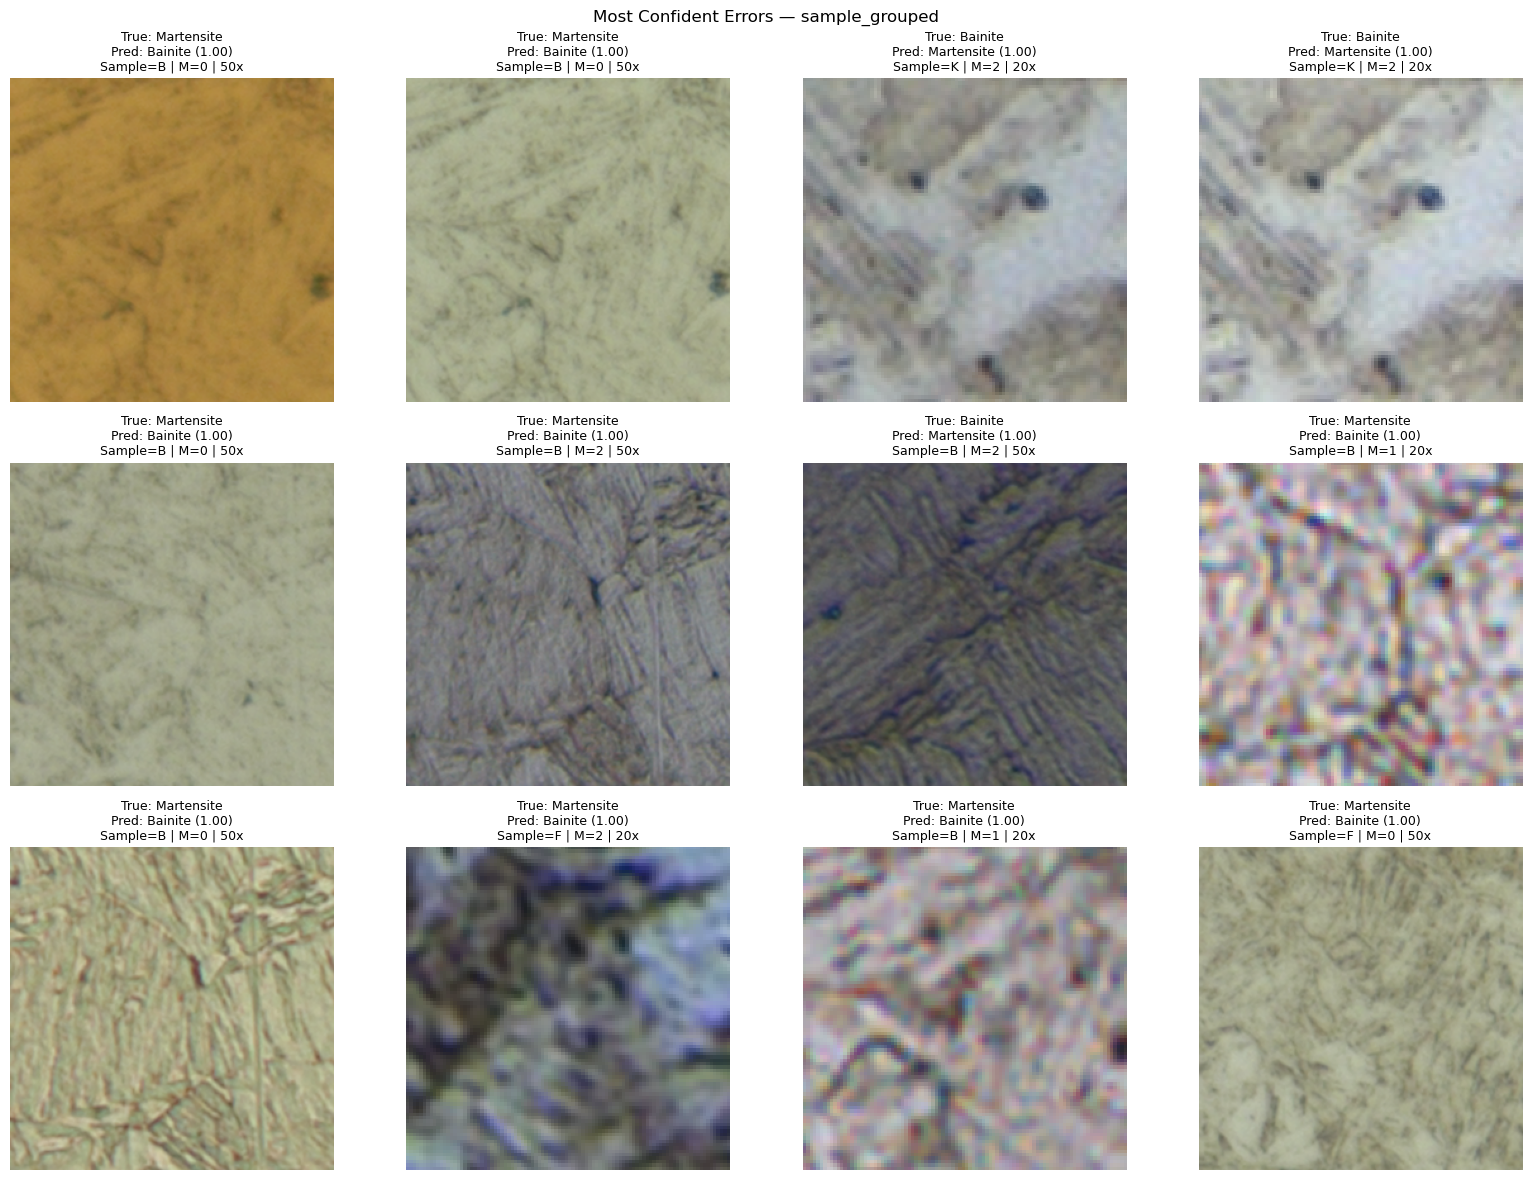

In [15]:
def show_errors(r,n=12):
    test=r["bundle"]["parts"]["test"].reset_index(drop=True)
    pred=pd.DataFrame({"idx":r["row_indices"],"true":r["y_true"],
                       "pred":r["y_pred"],"prob":r["y_prob"]})
    pred["confidence"]=np.where(pred["pred"]==1,pred["prob"],1-pred["prob"])
    wrong=pred[pred["true"]!=pred["pred"]].sort_values("confidence",ascending=False).head(n)
    if wrong.empty:return
    rows=int(np.ceil(len(wrong)/4));fig,axes=plt.subplots(rows,4,figsize=(16,4*rows))
    axes=np.asarray(axes).reshape(-1)
    for ax,(_,pr) in zip(axes,wrong.iterrows()):
        row=test.iloc[int(pr["idx"])]
        with Image.open(row["image_path"]) as img:ax.imshow(img.convert("RGB"))
        title=f"True: {CLASS_NAMES[int(pr['true'])]}\nPred: {CLASS_NAMES[int(pr['pred'])]} ({pr['confidence']:.2f})"
        if "SampleIDHarm" in row.index:title+=f"\nSample={row['SampleIDHarm']}"
        if "MicroscopeID" in row.index:title+=f" | M={row['MicroscopeID']}"
        if "Magnification" in row.index:title+=f" | {row['Magnification']}"
        ax.set_title(title,fontsize=9);ax.axis("off")
    for ax in axes[len(wrong):]:ax.axis("off")
    fig.suptitle(f"Most Confident Errors — {r['name']}");fig.tight_layout();plt.show()

show_errors(standard_result)
show_errors(grouped_result)


# Part G — Direct comparison with Notebook 03


In [16]:
cnn={
"Standard stratified":{"Accuracy":.7809,"Balanced Accuracy":.7781,"Macro F1":.7789,"ROC-AUC":.8582},
"Unseen physical samples":{"Accuracy":.6487,"Balanced Accuracy":.6400,"Macro F1":.6405,"ROC-AUC":.7094}
}
rows=[]
for ev,v in cnn.items():rows.append({"Model":"Custom CNN","Evaluation":ev,**v})
for r,ev in [(standard_result,"Standard stratified"),(grouped_result,"Unseen physical samples")]:
    m=r["test_metrics"]
    rows.append({"Model":"ResNet18 transfer learning","Evaluation":ev,
                 "Accuracy":m["accuracy"],"Balanced Accuracy":m["balanced_accuracy"],
                 "Macro F1":m["f1_macro"],"ROC-AUC":m["roc_auc"]})
comparison=pd.DataFrame(rows)
display(comparison.style.format({"Accuracy":"{:.4f}","Balanced Accuracy":"{:.4f}",
                                 "Macro F1":"{:.4f}","ROC-AUC":"{:.4f}"}))
comparison.to_csv(RESULT_DIR/"cnn_vs_resnet18.csv",index=False)

for ev in ["Standard stratified","Unseen physical samples"]:
    print("\n"+ev.upper())
    a=comparison[(comparison.Model=="Custom CNN")&(comparison.Evaluation==ev)].iloc[0]
    b=comparison[(comparison.Model=="ResNet18 transfer learning")&(comparison.Evaluation==ev)].iloc[0]
    for metric in ["Accuracy","Balanced Accuracy","Macro F1","ROC-AUC"]:
        print(f"{metric:20s}: {b[metric]-a[metric]:+.4f} ResNet18 − CNN")


,Model,Evaluation,Accuracy,Balanced Accuracy,Macro F1,ROC-AUC
0,Custom CNN,Standard stratified,0.7809,0.7781,0.7789,0.8582
1,Custom CNN,Unseen physical samples,0.6487,0.6400,0.6405,0.7094
2,ResNet18 transfer learning,Standard stratified,0.9610,0.9604,0.9608,0.9934
3,ResNet18 transfer learning,Unseen physical samples,0.6711,0.6829,0.6702,0.7747



STANDARD STRATIFIED
Accuracy            : +0.1801 ResNet18 − CNN
Balanced Accuracy   : +0.1823 ResNet18 − CNN
Macro F1            : +0.1819 ResNet18 − CNN
ROC-AUC             : +0.1352 ResNet18 − CNN

UNSEEN PHYSICAL SAMPLES
Accuracy            : +0.0224 ResNet18 − CNN
Balanced Accuracy   : +0.0429 ResNet18 − CNN
Macro F1            : +0.0297 ResNet18 − CNN
ROC-AUC             : +0.0653 ResNet18 − CNN


## 10. Generalization-gap comparison


CNN Macro-F1 gap     : 0.1384
ResNet18 Macro-F1 gap: 0.2905


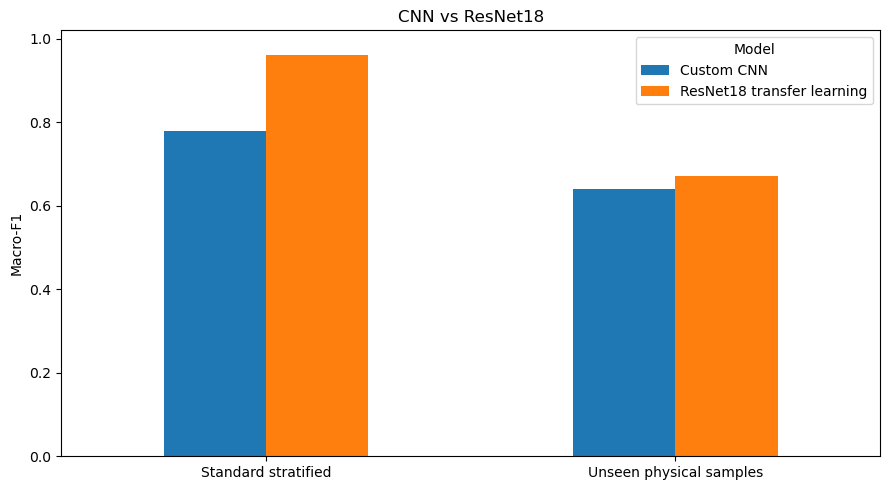

In [17]:
def val(model,ev,metric):
    return comparison.loc[(comparison.Model==model)&(comparison.Evaluation==ev),metric].iloc[0]

cnn_gap=val("Custom CNN","Standard stratified","Macro F1")-val("Custom CNN","Unseen physical samples","Macro F1")
resnet_gap=val("ResNet18 transfer learning","Standard stratified","Macro F1")-val("ResNet18 transfer learning","Unseen physical samples","Macro F1")

print(f"CNN Macro-F1 gap     : {cnn_gap:.4f}")
print(f"ResNet18 Macro-F1 gap: {resnet_gap:.4f}")

p=comparison.pivot(index="Evaluation",columns="Model",values="Macro F1")
fig,ax=plt.subplots(figsize=(9,5));p.plot(kind="bar",ax=ax)
ax.set_ylim(0,1.02);ax.set_ylabel("Macro-F1");ax.set_xlabel("")
ax.set_title("CNN vs ResNet18");ax.tick_params(axis="x",rotation=0)
fig.tight_layout();plt.show()


## 11. Save prediction-level results


In [18]:
def save_predictions(r):
    test=r["bundle"]["parts"]["test"].reset_index(drop=True)
    pred=pd.DataFrame({"dataset_index":r["row_indices"],"true_label":r["y_true"],
                       "predicted_label":r["y_pred"],"p_martensite":r["y_prob"]})
    pred["true_phase"]=pred["true_label"].map({0:"Bainite",1:"Martensite"})
    pred["predicted_phase"]=pred["predicted_label"].map({0:"Bainite",1:"Martensite"})
    meta=test.iloc[pred["dataset_index"]].reset_index(drop=True)
    keep=[c for c in ["image_path","filename","SampleIDHarm","MicroscopeID","Magnification","PatchID"] if c in meta]
    pd.concat([meta[keep].reset_index(drop=True),pred],axis=1).to_csv(
        RESULT_DIR/f"{r['name']}_test_predictions.csv",index=False)

save_predictions(standard_result);save_predictions(grouped_result)
print("Prediction-level results saved.")


Prediction-level results saved.


# 12. Final summary

The most important number is the unseen-sample Macro-F1 relative to the CNN baseline of **0.6405**. Standard-split improvement is useful, but it does not by itself demonstrate specimen-level generalization.


In [19]:
print("="*84)
print("TRANSFER LEARNING SUMMARY")
print("="*84)
for r,label in [(standard_result,"Standard stratified"),(grouped_result,"Unseen physical samples")]:
    m=r["test_metrics"]
    print(f"\n{label}")
    print(f"  Accuracy          : {m['accuracy']:.4f}")
    print(f"  Balanced Accuracy : {m['balanced_accuracy']:.4f}")
    print(f"  Macro-F1          : {m['f1_macro']:.4f}")
    print(f"  ROC-AUC           : {m['roc_auc']:.4f}")
    print(f"  Training time     : {r['minutes']:.2f} min")

print("\nCOMPARISON WITH CUSTOM CNN")
print("  CNN unseen-sample Macro-F1    : 0.6405")
print(f"  ResNet unseen-sample Macro-F1 : {grouped_result['test_metrics']['f1_macro']:.4f}")
print(f"  Improvement                   : {grouped_result['test_metrics']['f1_macro']-.6405:+.4f}")

print("\nGENERALIZATION GAP")
print(f"  CNN     : {cnn_gap:.4f}")
print(f"  ResNet18: {resnet_gap:.4f}")
print("\nSaved checkpoints:")
print(" •",standard_result["checkpoint"]);print(" •",grouped_result["checkpoint"])
print("="*84)


TRANSFER LEARNING SUMMARY

Standard stratified
  Accuracy          : 0.9610
  Balanced Accuracy : 0.9604
  Macro-F1          : 0.9608
  ROC-AUC           : 0.9934
  Training time     : 70.35 min

Unseen physical samples
  Accuracy          : 0.6711
  Balanced Accuracy : 0.6829
  Macro-F1          : 0.6702
  ROC-AUC           : 0.7747
  Training time     : 45.03 min

COMPARISON WITH CUSTOM CNN
  CNN unseen-sample Macro-F1    : 0.6405
  ResNet unseen-sample Macro-F1 : 0.6702
  Improvement                   : +0.0297

GENERALIZATION GAP
  CNN     : 0.1384
  ResNet18: 0.2905

Saved checkpoints:
 • ..\models\04_transfer_learning\standard_stratified_resnet18_best.pt
 • ..\models\04_transfer_learning\sample_grouped_resnet18_best.pt


# What to send back

Send the final **TRANSFER LEARNING SUMMARY** after both experiments finish.

Also keep the learning curves. The notebook permits up to **40 epochs per experiment**. Early stopping is intentional: if validation Macro-F1 has stopped improving for eight epochs, continuing simply to reach an arbitrary epoch count is unlikely to be the best use of CPU time.

If ResNet18 materially improves unseen-sample performance, it becomes the candidate backbone for Notebook 05's cross-microscope generalization experiments.
